# Test Trinary Mask Generation

This notebook tests the trinary observation strategy implementation to verify it generates the expected semantic masks.

Expected pattern:
- Bird pixels (-1) should appear around row 7-8, columns 9-11
- Pipe pixels (1) should appear in rightmost columns
- Background (0) everywhere else

We'll capture frames every 5 steps for 100 steps to see how the mask evolves.


In [1]:
import flappy_bird_env  # noqa
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from evaluator import FlappyBirdEvaluator, FlappyBirdEvaluatorConfig

print("✓ Libraries imported successfully")


✓ Libraries imported successfully


In [2]:
# Create FlappyBirdEvaluator with trinary strategy
config = FlappyBirdEvaluatorConfig(
    env_id="FlappyBird-v0",
    render_mode="rgb_array",
    patch_strategy="trinary",
    frame_stack_size=1,  # No frame stacking for this test
    trinary_crop_bottom=100,
    trinary_resize_factor=0.03,
    trinary_final_size=21,
    trinary_bird_h_min=0,
    trinary_bird_h_max=50,
    trinary_bird_s_min=50,
    trinary_bird_s_max=255,
    trinary_bird_v_min=50,
    trinary_bird_v_max=255,
    trinary_pipe_h_min=35,
    trinary_pipe_h_max=45,
    trinary_pipe_s_min=40,
    trinary_pipe_s_max=255,
    trinary_pipe_v_min=40,
    trinary_pipe_v_max=255,
    rng_seed=42
)

evaluator = FlappyBirdEvaluator(config)
print("✓ FlappyBirdEvaluator created with trinary strategy")


✓ FlappyBirdEvaluator created with trinary strategy


In [3]:
# Capture frames and generate masks
observation, _ = evaluator.env.reset(seed=42)
observation = np.asarray(observation, dtype=np.float32)

# Reset frame buffer
evaluator.frame_buffer = None

captured_frames = []
max_steps = 100
capture_interval = 5  # Capture every 5 steps

for step in range(max_steps):
    # Generate mask from current observation (evaluator expects float32)
    processed = evaluator._process_observation(observation)
    mask_list, obs_type = processed
    mask = mask_list[0]  # Get the single mask (no frame stacking)
    
    # Capture frame every N steps (store RGB as uint8 for display)
    if step % capture_interval == 0:
        captured_frames.append({
            'step': step,
            'rgb': observation.astype(np.uint8).copy(),  # Store as uint8 for visualization
            'mask': mask.copy()
        })
    
    # Take action (occasionally flap to keep bird alive)
    action = 1 if step % 10 == 0 else 0
    observation, reward, terminated, truncated, _ = evaluator.env.step(action)
    observation = np.asarray(observation, dtype=np.float32)
    
    if terminated or truncated:
        observation, _ = evaluator.env.reset(seed=42 + step)
        observation = np.asarray(observation, dtype=np.float32)
        evaluator.frame_buffer = None  # Reset frame buffer

evaluator.env.close()

print(f"✓ Captured {len(captured_frames)} frames")
print(f"Mask shape: {captured_frames[0]['mask'].shape}")
print(f"Mask dtype: {captured_frames[0]['mask'].dtype}")
print(f"Mask unique values: {np.unique(captured_frames[0]['mask'])}")


✓ Captured 20 frames
Mask shape: (21, 21)
Mask dtype: float32
Mask unique values: [-1.  0.]


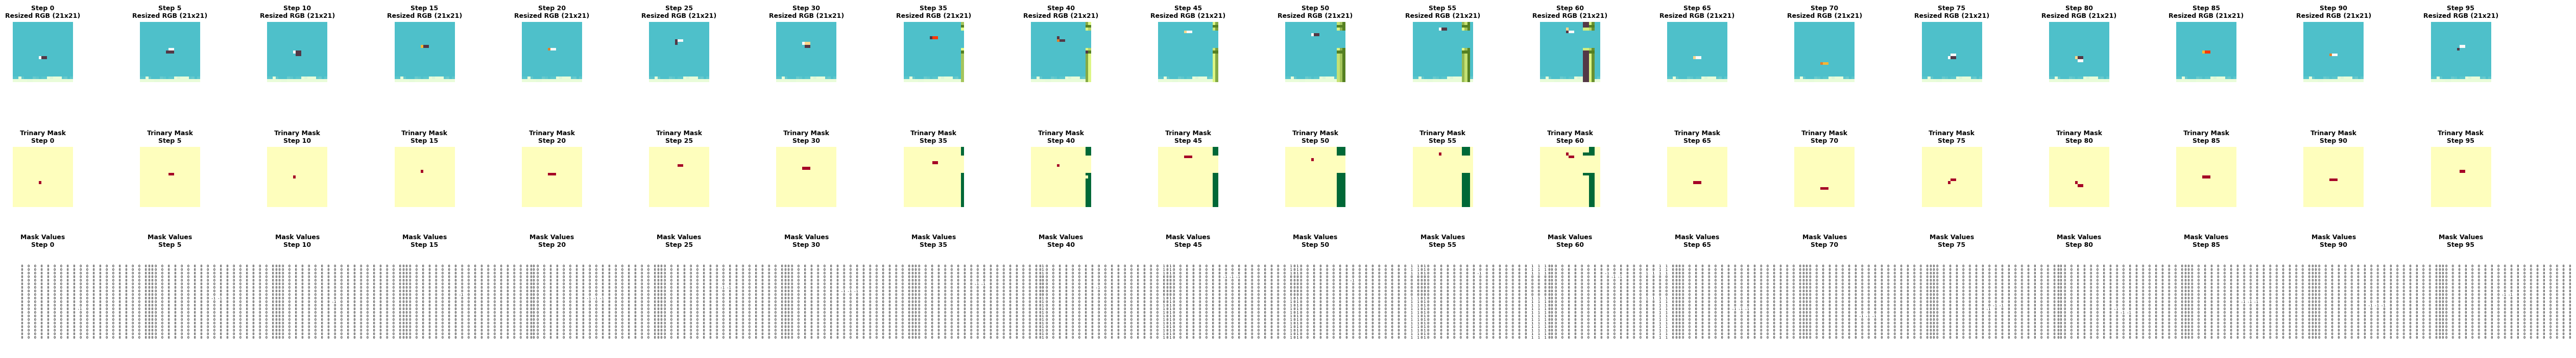

In [4]:
# Display captured masks
import cv2

num_frames = len(captured_frames)
fig, axes = plt.subplots(3, num_frames, figsize=(2.5*num_frames, 7.5))

if num_frames == 1:
    axes = axes.reshape(-1, 1)

for idx, frame_data in enumerate(captured_frames):
    step = frame_data['step']
    mask = frame_data['mask']
    rgb = frame_data['rgb']  # Already uint8
    
    # Row 1: Original RGB (cropped and resized for reference)
    h, w = rgb.shape[:2]
    cropped_rgb = rgb[:h-100, :]
    if config.trinary_resize_factor != 1.0:
        new_h = max(1, int(cropped_rgb.shape[0] * config.trinary_resize_factor))
        new_w = max(1, int(cropped_rgb.shape[1] * config.trinary_resize_factor))
        resized_rgb = cv2.resize(cropped_rgb, (new_w, new_h), 
                                interpolation=cv2.INTER_NEAREST)
        resized_rgb = cv2.resize(resized_rgb, (21, 21), 
                                interpolation=cv2.INTER_NEAREST)
    else:
        resized_rgb = cv2.resize(cropped_rgb, (21, 21), 
                                interpolation=cv2.INTER_NEAREST)
    
    axes[0, idx].imshow(resized_rgb)
    axes[0, idx].set_title(f"Step {step}\nResized RGB (21x21)", fontsize=9, fontweight='bold')
    axes[0, idx].axis('off')
    
    # Row 2: Trinary mask
    im = axes[1, idx].imshow(mask, cmap='RdYlGn', vmin=-1, vmax=1)
    axes[1, idx].set_title(f"Trinary Mask\nStep {step}", fontsize=9, fontweight='bold')
    axes[1, idx].axis('off')
    
    # Row 3: Mask values as text
    axes[2, idx].axis('off')
    mask_text = '\n'.join([' '.join([f'{int(val):2d}' for val in row]) for row in mask])
    axes[2, idx].text(0.1, 0.5, mask_text, fontsize=5, family='monospace', 
                      verticalalignment='center', horizontalalignment='left')
    axes[2, idx].set_title(f"Mask Values\nStep {step}", fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


In [ ]:
# Print the actual mask matrix for first captured frame
if len(captured_frames) > 0:
    first_mask = captured_frames[0]['mask']
    print("First captured mask matrix:")
    print(first_mask)
    print("\nMask statistics:")
    print(f"  Shape: {first_mask.shape}")
    print(f"  Unique values: {np.unique(first_mask)}")
    print(f"  Bird pixels (-1): {np.sum(first_mask == -1)}")
    print(f"  Background pixels (0): {np.sum(first_mask == 0)}")
    print(f"  Pipe pixels (1): {np.sum(first_mask == 1)}")
    
    # Check if it matches expected pattern (bird at row 7-8, cols 9-11, pipes at right)e
    print("\nExpected pattern check:")
    print(f"  Bird region (rows 7-8, cols 9-11): {first_mask[7:9, 9:12]}")
    print(f"  Rightmost columns (last 2 cols): {first_mask[:, -2:]}")


First captured mask matrix:
[[ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0

In [6]:
# Compare with expected pattern
expected_pattern = np.array([
    [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1],
    [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1],
    [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1],
    [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1],
    [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1],
    [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1],
    [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1],
    [ 0,  0,  0,  0,  0,  0,  0,  0,  0, -1, -1, -1,  0,  0,  0,  0,  0,  0,  0,  1,  1],
    [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1],
    [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1],
    [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1],
    [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1],
    [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
    [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
    [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
    [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
    [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
    [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
    [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1],
    [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1],
    [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1]
], dtype=np.float32)

print("Expected pattern shape:", expected_pattern.shape)
print("Expected pattern unique values:", np.unique(expected_pattern))

if len(captured_frames) > 0:
    first_mask = captured_frames[0]['mask']
    print("\nActual mask shape:", first_mask.shape)
    print("Actual mask unique values:", np.unique(first_mask))
    
    # Check if shapes match
    if first_mask.shape == expected_pattern.shape:
        print("\n✓ Shapes match!")
        
        # Calculate similarity
        matches = np.sum(first_mask == expected_pattern)
        total = first_mask.size
        similarity = matches / total * 100
        
        print(f"\nSimilarity check:")
        print(f"  Matching pixels: {matches} / {total} ({similarity:.1f}%)")
        
        if matches == total:
            print("  ✓ Perfect match!")
        else:
            print("  ⚠ Patterns differ (this is expected - actual masks depend on game state)")
            
            # Show differences
            diff_mask = first_mask != expected_pattern
            print(f"\nDifferences found at {np.sum(diff_mask)} pixels")
    else:
        print("\n✗ Shapes don't match!")


Expected pattern shape: (21, 21)
Expected pattern unique values: [-1.  0.  1.]

Actual mask shape: (21, 21)
Actual mask unique values: [-1.  0.]

✓ Shapes match!

Similarity check:
  Matching pixels: 407 / 441 (92.3%)
  ⚠ Patterns differ (this is expected - actual masks depend on game state)

Differences found at 34 pixels
